**Task 2**

In [ ]:
from tensorflow.keras.datasets import cifar10

(X_train_img, y_train_img), (X_test_img, y_test_img) = cifar10.load_data()
y_train_img = y_train_img.flatten()
y_test_img = y_test_img.flatten()

print(X_train_img.shape, X_test_img.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 743s 4us/step
(50000, 32, 32, 3) (10000, 32, 32, 3)


In [ ]:
def subsample(X, y, n_per_class, seed=42):
    rng = np.random.RandomState(seed)
    idx_list = []
    for c in range(10):
        class_idx = np.where(y == c)[0]
        chosen = rng.choice(class_idx, n_per_class, replace=False)
        idx_list.append(chosen)
    idx = np.concatenate(idx_list)
    rng.shuffle(idx)
    return X[idx], y[idx]

X_train_img_s, y_train_cifar = subsample(X_train_img, y_train_img, 500)
X_test_img_s, y_test_cifar = subsample(X_test_img, y_test_img, 100)

print(X_train_img_s.shape, X_test_img_s.shape)

(5000, 32, 32, 3) (1000, 32, 32, 3)


In [ ]:
X_train_cifar = X_train_img_s.reshape(X_train_img_s.shape[0], -1).astype(float) / 255.0
X_test_cifar = X_test_img_s.reshape(X_test_img_s.shape[0], -1).astype(float) / 255.0

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print(X_train_cifar.shape, X_test_cifar.shape)

(5000, 3072) (1000, 3072)


In [ ]:
K_values = [3, 4, 9, 20, 47]
results_cifar = []

for metric_name, dist_func in DISTANCE_FUNCS.items():
    for k in K_values:
        model = KNNClassifier(k=k, distance_func=dist_func).fit(X_train_cifar, y_train_cifar)
        y_pred = model.predict(X_test_cifar)
        acc = accuracy(y_test_cifar, y_pred)
        results_cifar.append({'K': k, 'Metric': metric_name, 'Accuracy': acc})
        print(f"K={k:>2} | {metric_name:<16} | Test Accuracy = {acc:.4f}")

results_df_cifar = pd.DataFrame(results_cifar)

K= 3 | Euclidean        | Test Accuracy = 0.2630
K= 4 | Euclidean        | Test Accuracy = 0.3020
K= 9 | Euclidean        | Test Accuracy = 0.2800
K=20 | Euclidean        | Test Accuracy = 0.3000
K=47 | Euclidean        | Test Accuracy = 0.2740
K= 3 | Manhattan        | Test Accuracy = 0.3040
K= 4 | Manhattan        | Test Accuracy = 0.2920
K= 9 | Manhattan        | Test Accuracy = 0.3060
K=20 | Manhattan        | Test Accuracy = 0.3130
K=47 | Manhattan        | Test Accuracy = 0.3060
K= 3 | Minkowski (p=3)  | Test Accuracy = 0.2530
K= 4 | Minkowski (p=3)  | Test Accuracy = 0.2690
K= 9 | Minkowski (p=3)  | Test Accuracy = 0.2690
K=20 | Minkowski (p=3)  | Test Accuracy = 0.2700
K=47 | Minkowski (p=3)  | Test Accuracy = 0.2510
K= 3 | Cosine           | Test Accuracy = 0.2820
K= 4 | Cosine           | Test Accuracy = 0.2820
K= 9 | Cosine           | Test Accuracy = 0.3010
K=20 | Cosine           | Test Accuracy = 0.2960
K=47 | Cosine           | Test Accuracy = 0.2900
K= 3 | Hamming      

In [ ]:
pivot_cifar = results_df_cifar.pivot(index='K', columns='Metric', values='Accuracy')
pivot_cifar

Metric,Cosine,Euclidean,Hamming,Manhattan,Minkowski (p=3)
K,,,,,
3,0.282,0.263,0.228,0.304,0.253
4,0.282,0.302,0.224,0.292,0.269
9,0.301,0.280,0.239,0.306,0.269
20,0.296,0.300,0.263,0.313,0.270
47,0.290,0.274,0.269,0.306,0.251


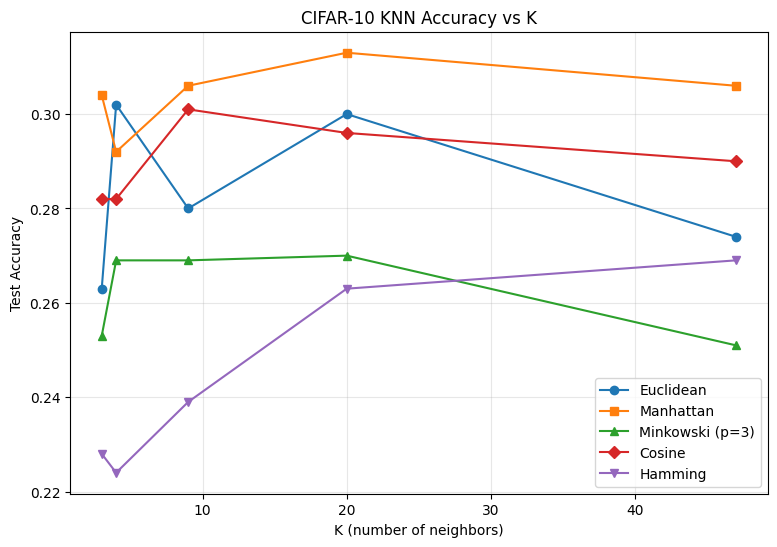

In [ ]:
plt.figure(figsize=(9, 6))
markers = ['o', 's', '^', 'D', 'v']
for (metric_name, _), marker in zip(DISTANCE_FUNCS.items(), markers):
    sub = results_df_cifar[results_df_cifar['Metric'] == metric_name].sort_values('K')
    plt.plot(sub['K'], sub['Accuracy'], marker=marker, label=metric_name)

plt.xlabel('K (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.title('CIFAR-10 KNN Accuracy vs K')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
best_row_cifar = results_df_cifar.loc[results_df_cifar['Accuracy'].idxmax()]
best_k_cifar = int(best_row_cifar['K'])
best_metric_cifar = best_row_cifar['Metric']
best_acc_cifar = best_row_cifar['Accuracy']

print(f"Best combination -> K = {best_k_cifar}, Distance metric = {best_metric_cifar}, Test Accuracy = {best_acc_cifar:.4f}")

Best combination -> K = 20, Distance metric = Manhattan, Test Accuracy = 0.3130


In [ ]:
def confusion_matrix_multiclass(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def precision_recall_multiclass(cm):
    precision = np.diag(cm) / (cm.sum(axis=0) + 1e-8)
    recall = np.diag(cm) / (cm.sum(axis=1) + 1e-8)
    return precision, recall

best_model_cifar = KNNClassifier(k=best_k_cifar, distance_func=DISTANCE_FUNCS[best_metric_cifar]).fit(X_train_cifar, y_train_cifar)
y_pred_best_cifar = best_model_cifar.predict(X_test_cifar)

cm_cifar = confusion_matrix_multiclass(y_test_cifar, y_pred_best_cifar)
precision_cifar, recall_cifar = precision_recall_multiclass(cm_cifar)

for i, name in enumerate(class_names):
    print(f"{name:<12} precision={precision_cifar[i]:.3f}  recall={recall_cifar[i]:.3f}")

print(f"\nOverall Accuracy = {accuracy(y_test_cifar, y_pred_best_cifar):.4f}")
print(f"Macro Precision  = {precision_cifar.mean():.4f}")
print(f"Macro Recall     = {recall_cifar.mean():.4f}")

airplane     precision=0.411  recall=0.600
automobile   precision=0.615  recall=0.080
bird         precision=0.213  recall=0.370
cat          precision=0.348  recall=0.080
deer         precision=0.219  recall=0.560
dog          precision=0.413  recall=0.190
frog         precision=0.214  recall=0.220
horse        precision=0.480  recall=0.120
ship         precision=0.374  recall=0.650
truck        precision=0.650  recall=0.260

Overall Accuracy = 0.3130
Macro Precision  = 0.3936
Macro Recall     = 0.3130


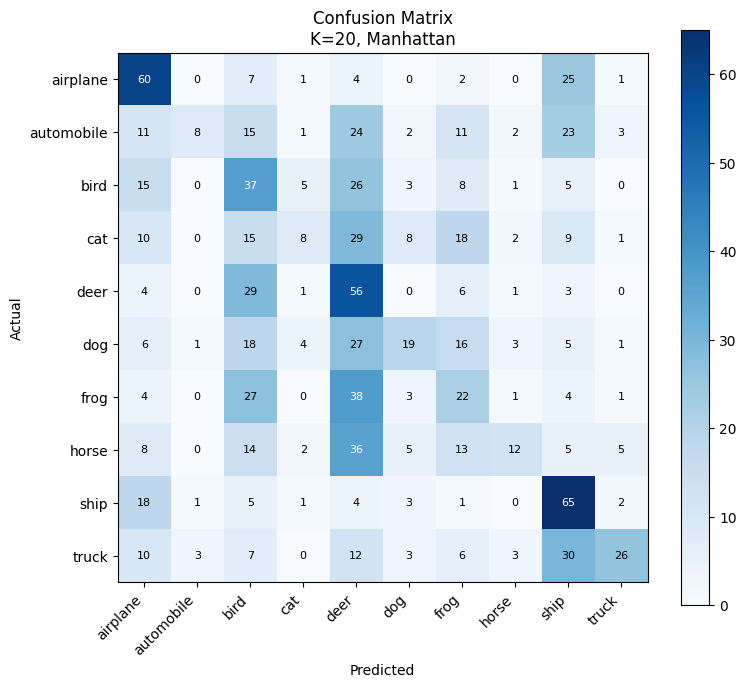

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_cifar, cmap='Blues')
ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticks(range(10)); ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix\nK={best_k_cifar}, {best_metric_cifar}')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm_cifar[i, j], ha='center', va='center',
                color='white' if cm_cifar[i, j] > cm_cifar.max()/2 else 'black', fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.show()

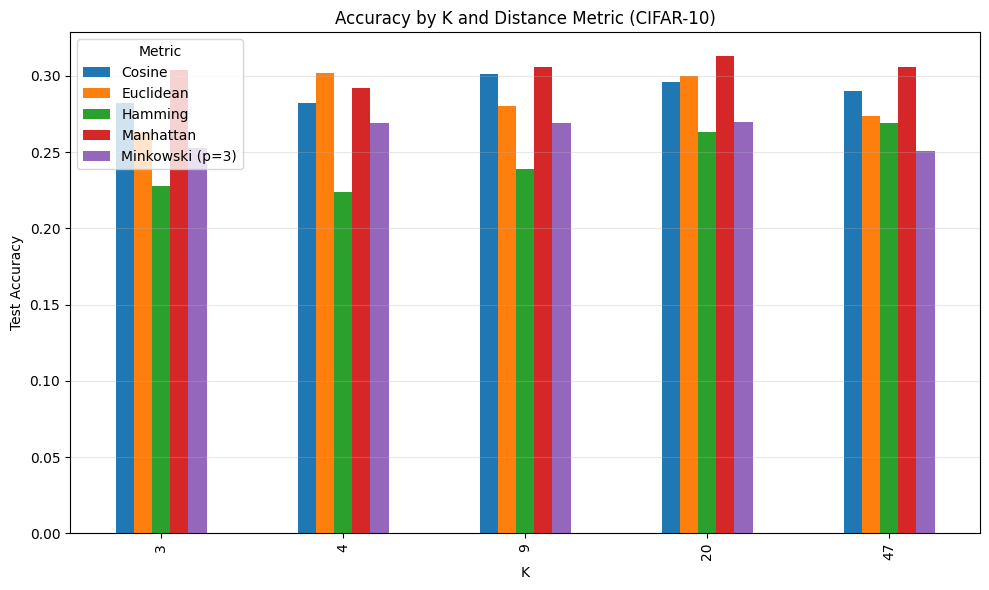

In [ ]:
pivot_cifar.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Test Accuracy')
plt.title('Accuracy by K and Distance Metric (CIFAR-10)')
plt.legend(title='Metric')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()